# Revolut case study

### Import packages

In [1]:
import numpy as np
import pandas as pd
import ast # For converting string like data to dict

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter

import seaborn as sns

C:\Users\pitla\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Import files
doc_report = pd.read_csv('doc_report.csv', )
facial_report = pd.read_csv('facial_similarity_report.csv')

## 1 Exploratory data analysis

### 1.1 Explore document report

In [3]:
# View the data 
doc_report.head()

,number,user_id,result,visual_authenticity_result,image_integrity_result,face_detection_result,image_quality_result,created_at,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,attempt_id,police_record_result,compromised_document_result,properties,sub_result
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,consider,consider,clear,clear,clear,2017-06-20T23:12:57Z,clear,NaN,NaN,clear,clear,NaN,050a0596de424fab83c433eaa18b3f8d,clear,NaN,"{'gender': 'Male', 'nationality': 'IRL', 'docu...",caution
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,clear,clear,clear,2017-06-20T23:16:04Z,clear,NaN,NaN,clear,NaN,NaN,f69c1e5f45a64e50a26740b9bfb978b7,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,clear,clear,clear,2017-06-20T17:59:49Z,clear,NaN,NaN,clear,clear,NaN,f9f84f3055714d8e8f7419dc984d1769,clear,NaN,"{'gender': 'Male', 'nationality': 'ITA', 'docu...",clear
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,clear,clear,clear,2017-06-20T17:59:38Z,clear,NaN,NaN,clear,clear,NaN,10a54a1ecf794404be959e030f11fef6,clear,NaN,"{'gender': 'Male', 'issuing_date': '2007-08', ...",clear
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,clear,clear,clear,2017-06-20T18:08:09Z,clear,NaN,NaN,clear,clear,NaN,1f320d1d07de493292b7e0d5ebfb1cb9,clear,NaN,"{'gender': 'Male', 'nationality': 'POL', 'docu...",clear


In [4]:
# Gathering info on the dataset 
doc_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   number                              176404 non-null  int64 
 1   user_id                             176404 non-null  object
 2   result                              176404 non-null  object
 3   visual_authenticity_result          150290 non-null  object
 4   image_integrity_result              176403 non-null  object
 5   face_detection_result               150261 non-null  object
 6   image_quality_result                176403 non-null  object
 7   created_at                          176404 non-null  object
 8   supported_document_result           175900 non-null  object
 9   conclusive_document_quality_result  95217 non-null   object
 10  colour_picture_result               95222 non-null   object
 11  data_validation_result              142

#### Initial findings: 
- Attempt_id in the middle of the table 
- Properties column containing dict like data
- Date type needs to be changed for doc create date
- Property columns containing multiple data points related to submitted documents

In [5]:
# Avoid issues with large numeric IDs 
doc_report['user_id'] = doc_report['user_id'].astype(str)
doc_report['attempt_id'] = doc_report['attempt_id'].astype(str)

In [6]:
# Move attempt ID to the front of the DF
cols = ['number','user_id','attempt_id'] + [col for col in doc_report.columns if col not in ['number','user_id','attempt_id']]
doc_report = doc_report[cols]

In [7]:
# Convert created_at to date 
doc_report['created_at'] = pd.to_datetime(doc_report['created_at'])

In [8]:
# Create a creation date column
doc_report['created_date'] = doc_report['created_at'].dt.date

#### Extract doc check report properties
Create new variable for each property

In [9]:
# Check data type of properties column 
doc_report['properties'].apply(type) 

0         <class 'str'>
1         <class 'str'>
2         <class 'str'>
3         <class 'str'>
4         <class 'str'>
              ...      
176399    <class 'str'>
176400    <class 'str'>
176401    <class 'str'>
176402    <class 'str'>
176403    <class 'str'>
Name: properties, Length: 176404, dtype: object

In [10]:
# Handling strings that look like dicts
# AST (Abstract Syntax Trees) allows you to process Python code as data

doc_report['properties'] = doc_report['properties'].apply(ast.literal_eval) # Only parses safe Python literals

In [11]:
# Set the dtype explicitly for any empty entries before applying .apply(pd.Series) to avoid warning message
doc_report['properties'] = doc_report['properties'].apply(lambda x: x if isinstance(x, dict) else {})

# Flatten the dict column
doc_expanded = doc_report['properties'].apply(pd.Series)

In [12]:
# View flattened data
doc_expanded

,gender,nationality,document_type,date_of_expiry,issuing_country,issuing_date,issuing_state,document_version
0,Male,IRL,passport,2019-08-12,IRL,NaN,NaN,NaN
1,Female,NaN,driving_licence,2023-02-28,GBR,NaN,NaN,NaN
2,Male,ITA,passport,2018-06-09,ITA,NaN,NaN,NaN
3,Male,NaN,national_identity_card,NaN,FRA,2007-08,NaN,NaN
4,Male,POL,national_identity_card,2019-05-29,POL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
176399,Female,CHN,passport,2027-04-23,CHN,NaN,NaN,NaN
176400,Female,NaN,driving_licence,2026-04-20,GBR,NaN,NaN,NaN
176401,Female,GBR,passport,2023-07-11,GBR,NaN,NaN,NaN
176402,Male,PRT,passport,2019-10-16,PRT,NaN,NaN,NaN


In [13]:
# Add user and attempt IDs to the dataset 
doc_expanded[['user_id','attempt_id']] = doc_report[['user_id','attempt_id']]

# Move ID columns to the front
cols = ['user_id','attempt_id'] + [col for col in doc_expanded.columns if col not in ['user_id','attempt_id']]
doc_expanded = doc_expanded[cols]

In [14]:
# See the dataset
doc_expanded

,user_id,attempt_id,gender,nationality,document_type,date_of_expiry,issuing_country,issuing_date,issuing_state,document_version
0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,Male,IRL,passport,2019-08-12,IRL,NaN,NaN,NaN
1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,Female,NaN,driving_licence,2023-02-28,GBR,NaN,NaN,NaN
2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,Male,ITA,passport,2018-06-09,ITA,NaN,NaN,NaN
3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,Male,NaN,national_identity_card,NaN,FRA,2007-08,NaN,NaN
4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,Male,POL,national_identity_card,2019-05-29,POL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
176399,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,Female,CHN,passport,2027-04-23,CHN,NaN,NaN,NaN
176400,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,Female,NaN,driving_licence,2026-04-20,GBR,NaN,NaN,NaN
176401,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,Female,GBR,passport,2023-07-11,GBR,NaN,NaN,NaN
176402,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,Male,PRT,passport,2019-10-16,PRT,NaN,NaN,NaN


In [15]:
# Convert date of expiry date to date format
doc_expanded['date_of_expiry'] = pd.to_datetime(doc_expanded['date_of_expiry'], errors='coerce').dt.date

In [16]:
# Convert date of issuing date to date format
doc_expanded['issuing_date'] = pd.to_datetime(doc_expanded['issuing_date'], errors='coerce').dt.date

### 1.2 Explore facial similarity report

In [17]:
# View first few rows of the dataset
facial_report.head()

,number,user_id,result,face_comparison_result,created_at,facial_image_integrity_result,visual_authenticity_result,properties,attempt_id
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,clear,clear,2017-06-20T23:12:58Z,clear,consider,{},050a0596de424fab83c433eaa18b3f8d
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,2017-06-20T23:16:04Z,clear,clear,{},f69c1e5f45a64e50a26740b9bfb978b7
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,2017-06-20T17:59:49Z,clear,clear,{},f9f84f3055714d8e8f7419dc984d1769
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,2017-06-20T17:59:39Z,clear,clear,{},10a54a1ecf794404be959e030f11fef6
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,2017-06-20T18:08:09Z,clear,clear,{},1f320d1d07de493292b7e0d5ebfb1cb9


In [18]:
# Get a summary of the DataFrame (structure, data types, missing values)
facial_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   number                         176404 non-null  int64 
 1   user_id                        176404 non-null  object
 2   result                         176403 non-null  object
 3   face_comparison_result         166007 non-null  object
 4   created_at                     176404 non-null  object
 5   facial_image_integrity_result  175941 non-null  object
 6   visual_authenticity_result     150290 non-null  object
 7   properties                     176404 non-null  object
 8   attempt_id                     176404 non-null  object
dtypes: int64(1), object(8)
memory usage: 12.1+ MB


##### Initial findings:
- Attempt_id in the end of the table
- Date type needs to be changed for doc create date
- Property column seems unnecessary but further checks are required to verify

In [19]:
# Reorder columns to have IDs in the first two columns

# Get columns names 
cols = list(facial_report.columns)

# Move last column to second position
last_col = cols[-1]
new_order = [cols[0],cols[1],last_col] + cols[2:-1]

# Reorder the DF
facial_report = facial_report[new_order]

In [20]:
# Avoid issues with large numeric IDs 
facial_report['user_id'] = facial_report['user_id'].astype(str)
facial_report['attempt_id'] = facial_report['attempt_id'].astype(str)

In [21]:
# Convert created_at to date format
facial_report['created_at'] = pd.to_datetime(facial_report['created_at'])

In [22]:
# Check properties column: We suspect that they only contain {} and are not necessary
facial_report['properties_length'] = facial_report['properties'].str.len()

print(facial_report.groupby('properties_length').size())

# Express results as percentages
percentage_by_length = facial_report['properties_length'].value_counts(normalize=True) * 100
print(percentage_by_length)

properties_length
2     172921
14       324
15      3159
dtype: int64
properties_length
2     98.025555
15     1.790776
14     0.183669
Name: proportion, dtype: float64


In [23]:
# Check properties column
facial_report['properties'].value_counts(normalize=True) * 100

properties
{}                 98.025555
{'score': 0.69}     0.095803
{'score': 0.64}     0.092402
{'score': 0.63}     0.090134
{'score': 0.66}     0.090134
                     ...    
{'score': 0.1}      0.000567
{'score': 0.14}     0.000567
{'score': 0.88}     0.000567
{'score': 0.19}     0.000567
{'score': 0.21}     0.000567
Name: proportion, Length: 80, dtype: float64

In [24]:
facial_report

,number,user_id,attempt_id,result,face_comparison_result,created_at,facial_image_integrity_result,visual_authenticity_result,properties,properties_length
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,{},2
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,{},2
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,{},2
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,{},2
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,{},2
...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,{},2
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,{},2
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,{},2
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,{},2


#### Remove properties column
Drop properties due to missing data issues

In [25]:
facial_report.drop(columns=['properties','properties_length'],inplace=True)

### 2 Data preparation for analysis 
#### Merging document and facial check results
Create a subset of original DFs 

In [26]:
doc_report.columns

Index(['number', 'user_id', 'attempt_id', 'result',
       'visual_authenticity_result', 'image_integrity_result',
       'face_detection_result', 'image_quality_result', 'created_at',
       'supported_document_result', 'conclusive_document_quality_result',
       'colour_picture_result', 'data_validation_result',
       'data_consistency_result', 'data_comparison_result',
       'police_record_result', 'compromised_document_result', 'properties',
       'sub_result', 'created_date'],
      dtype='object')

In [27]:
doc_report_subset = doc_report.drop(['number','properties'],axis=1)

In [28]:
doc_report_subset = doc_report_subset.rename(columns ={
    'result':'doc_result',
    'created_at':'doc_created_at',
    'created_date':'doc_created_date',
    'sub_result':'doc_sub_result'
})

In [29]:
facial_report.columns

Index(['number', 'user_id', 'attempt_id', 'result', 'face_comparison_result',
       'created_at', 'facial_image_integrity_result',
       'visual_authenticity_result'],
      dtype='object')

In [30]:
facial_report_subset = facial_report.copy()

In [31]:
facial_report_subset = facial_report_subset.rename(columns = {
    'result':'facial_result',
    'created_at':'facial_created_at',
    'visual_authenticity_result':'facial_visual_authenticity_result'
})

In [32]:
facial_report_subset.columns

Index(['number', 'user_id', 'attempt_id', 'facial_result',
       'face_comparison_result', 'facial_created_at',
       'facial_image_integrity_result', 'facial_visual_authenticity_result'],
      dtype='object')

#### Merge Document and Facial test DFs 

In [33]:
combined_check_results = facial_report_subset.merge(doc_report_subset, on=['user_id','attempt_id'],how='left')

In [34]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,facial_visual_authenticity_result,doc_result,visual_authenticity_result,...,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,doc_sub_result,doc_created_date
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,consider,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,caution,2017-06-20
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20


#### Compare visual authenticty columns in the 2 tables
Comparison to check whether the column contains the same information in the two tables

In [35]:
# Compare the two columns with visual_authentity_results
combined_check_results['facial_visual_authenticity_result'].equals(combined_check_results['visual_authenticity_result'])

True

In [36]:
# Drop one visual authenticity column to avoid duplication
combined_check_results = combined_check_results.drop('facial_visual_authenticity_result',axis=1)

#### Adding check results as numeric values

Coding check pass/fail results as numeric values to facilitate further analysis

In [37]:
# Identify users who failed document check
combined_check_results['doc_check_fail'] = combined_check_results['doc_result'].apply(lambda x: 1 if x != 'clear' else 0)

In [38]:
# Identify users who failed facial check
combined_check_results['facial_check_fail'] = combined_check_results['facial_result'].map(lambda x: 1 if x !='clear' else 0)

In [39]:
# Identify users who failed both tests
combined_check_results['failed_both_checks'] = combined_check_results.apply(lambda row: 1 if row['doc_check_fail'] ==1 and row['facial_check_fail'] ==1 else 0, axis=1)

In [40]:
# Identify users who failed only the document check
combined_check_results['only_doc_check_fail'] = combined_check_results.apply(lambda row: 1 if row['doc_check_fail']==1 and row['facial_check_fail']==0 else 0, axis=1)

In [41]:
# Identify users who failed only the facial check
combined_check_results['only_facial_check_fail'] = combined_check_results.apply(lambda row: 1 if row['doc_check_fail']==0 and row['facial_check_fail']==1 else 0, axis=1)

In [42]:
# Users whoe passed KYC (both the facial and document check are clear) 
combined_check_results['kyc_pass'] = combined_check_results.apply(lambda row: 1 if row['facial_result']=='clear' and row['doc_result']=='clear' else 0,axis=1)

In [43]:
# Users with multiple tries
combined_check_results['user_id_count'] = combined_check_results.groupby('user_id')['user_id'].transform('count')

In [44]:
# Add order to show sequence of tests at user level
combined_check_results.loc[:,'order'] = combined_check_results.sort_values(by=['user_id','number']).groupby('user_id').cumcount()+1

### Users with multiple tests
Additional columns to easily identify users who attempted more checks often unnecessarily

In [45]:
# Create a new DF for users with multiple tries 
multiple_tries = combined_check_results[combined_check_results['user_id_count']>1]

In [46]:
# Create a copy of the original DF to avoid warnings
multiple_tries = multiple_tries.copy()

# Add new columns to identify unnecessary checks - checks not required due to previous passes - if relevant
multiple_tries.loc[:,'previous_kyc'] = multiple_tries.groupby('user_id')['kyc_pass'].shift(1)

multiple_tries.loc[:,'has_previous_pass'] = multiple_tries.groupby('user_id')['previous_kyc'].cummax()


In [47]:
multiple_tries.loc[:,'necessary_check'] = multiple_tries.apply(lambda row: 1 if row['order']==1 else 
                                                            1 if row['has_previous_pass'] !=1  else
                                                            0, axis=1
                                                           )

## 3 KYC result analysis
### 3.1 Users with necessary checks

In [48]:
# Only consider the relevant subset of users
required_tests = combined_check_results[~combined_check_results['attempt_id'].isin(multiple_tries[multiple_tries['necessary_check']==0]['attempt_id'])]

In [49]:
# Key drivers of failed tests
kyc_analysis = {
    'unique_users':[required_tests['user_id'].nunique()],
    'unique_failed_users':[required_tests[required_tests['kyc_pass']==0]['user_id'].nunique()],
    'total_check_count':[len(required_tests)],
    'failed_check_count':[len(required_tests[required_tests['kyc_pass'] == 0])],
    'only_facial_check_failed': [len(required_tests[(required_tests['only_facial_check_fail'] == 1)])],
    'only_doc_check_failed': [len(required_tests[(required_tests['only_doc_check_fail'] == 1)])],
    'failed_both_checks': [len(required_tests[(required_tests['failed_both_checks'] == 1)])] 
}
                             
# Convert to a DF
kyc_analysis_df = pd.DataFrame(kyc_analysis)

In [50]:
# Aggregate results
kyc_analysis_df

,unique_users,unique_failed_users,total_check_count,failed_check_count,only_facial_check_failed,only_doc_check_failed,failed_both_checks
0,142724,29645,166688,45241,4820,35420,5001


#### Visualising results

In [51]:
# KYC results over time
kyc_analysis = required_tests.groupby('doc_created_date').agg(
    unique_users = ('user_id','nunique'),
    unique_failed_users=('user_id', lambda x: required_tests.loc[x.index][required_tests.loc[x.index, 'kyc_pass'] == 0]['user_id'].nunique()),
    total_check_count=('user_id','count'),
    failed_check_count=('kyc_pass',lambda x: (x==0).sum()),
    facial_check_fail = ('facial_check_fail', lambda x: (x==1).sum()),
    doc_check_fail = ('doc_check_fail', lambda x: (x==1).sum()),
    only_facial_check_fail = ('only_facial_check_fail', lambda x: (x==1).sum()),
    only_doc_check_fail = ('only_doc_check_fail', lambda x: (x==1).sum()),
    failed_both_checks = ('failed_both_checks', lambda x: (x==1).sum()),
    
).reset_index()

In [52]:
required_tests.columns

Index(['number', 'user_id', 'attempt_id', 'facial_result',
       'face_comparison_result', 'facial_created_at',
       'facial_image_integrity_result', 'doc_result',
       'visual_authenticity_result', 'image_integrity_result',
       'face_detection_result', 'image_quality_result', 'doc_created_at',
       'supported_document_result', 'conclusive_document_quality_result',
       'colour_picture_result', 'data_validation_result',
       'data_consistency_result', 'data_comparison_result',
       'police_record_result', 'compromised_document_result', 'doc_sub_result',
       'doc_created_date', 'doc_check_fail', 'facial_check_fail',
       'failed_both_checks', 'only_doc_check_fail', 'only_facial_check_fail',
       'kyc_pass', 'user_id_count', 'order'],
      dtype='object')

In [53]:
kyc_analysis['pass_rate'] = 1-kyc_analysis['unique_failed_users']/kyc_analysis['unique_users']
kyc_analysis

,doc_created_date,unique_users,unique_failed_users,total_check_count,failed_check_count,facial_check_fail,doc_check_fail,only_facial_check_fail,only_doc_check_fail,failed_both_checks,pass_rate
0,2017-05-23,91,19,97,22,14,9,13,8,1,0.791209
1,2017-05-24,178,32,187,39,26,16,23,13,3,0.820225
2,2017-05-25,156,26,158,27,13,15,12,14,1,0.833333
3,2017-05-26,193,30,200,36,23,19,17,13,6,0.844560
4,2017-05-27,157,26,163,31,17,14,17,14,0,0.834395
...,...,...,...,...,...,...,...,...,...,...,...
156,2017-10-27,1529,494,1877,729,61,720,9,668,52,0.676913
157,2017-10-28,1210,261,1400,384,47,367,17,337,30,0.784298
158,2017-10-29,1168,248,1348,345,33,332,13,312,20,0.787671
159,2017-10-30,1136,253,1300,332,40,319,13,292,27,0.777289


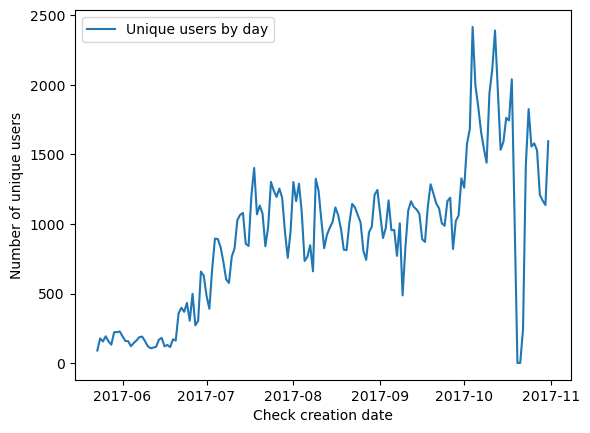

In [54]:
plt.plot(kyc_analysis['doc_created_date'], kyc_analysis['unique_users'],label='Unique users by day')
plt.xlabel('Check creation date')
plt.ylabel('Number of unique users')
plt.legend()
plt.show()

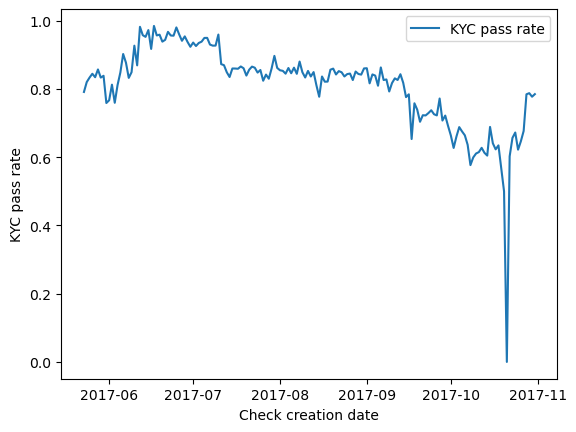

In [55]:
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['pass_rate'],label='KYC pass rate')
plt.legend()
plt.xlabel('Check creation date')
plt.ylabel('KYC pass rate')
plt.show()

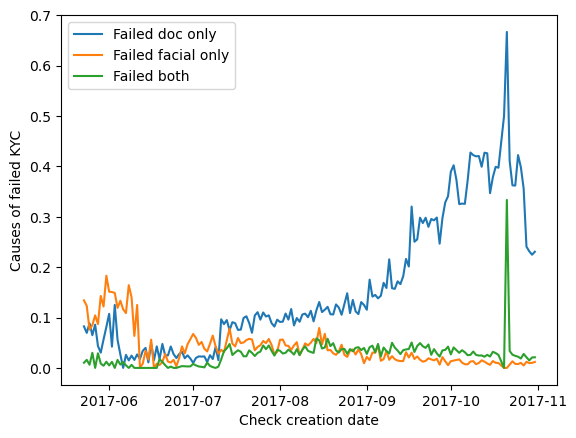

In [56]:
# Visualise drivers of failed KYC 
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['only_doc_check_fail'] /kyc_analysis['total_check_count'] ,label='Failed doc only')
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['only_facial_check_fail'] /kyc_analysis['total_check_count'] ,label='Failed facial only')
plt.plot(kyc_analysis['doc_created_date'],kyc_analysis['failed_both_checks'] /kyc_analysis['total_check_count'] ,label='Failed both')

plt.legend()
plt.xlabel('Check creation date')
plt.ylabel('Causes of failed KYC')
plt.show()

#### Deep dive into failed document checks
Analysis of document check sub-results to identify drivers

In [59]:
# Analysis of document check sub-results
doc_check_summary = required_tests['doc_sub_result'].value_counts().reset_index(name='count')
doc_check_summary['percentage'] = doc_check_summary['count'] / doc_check_summary['count'].sum()

In [60]:
doc_check_summary

,doc_sub_result,count,percentage
0,clear,126267,0.757505
1,rejected,24191,0.145127
2,caution,14484,0.086893
3,suspected,1746,0.010475


In [61]:
# Document check sub-result over time
doc_sub_result = required_tests.groupby('doc_created_date').agg(
    failed_doc_checks = ('doc_check_fail','sum'), 
    rejected_sub_result = ('doc_sub_result', lambda x: (x=='rejected').sum()),
    caution_sub_result = ('doc_sub_result', lambda x: (x=='caution').sum()),
).reset_index()

In [62]:
doc_sub_result

,doc_created_date,failed_doc_checks,rejected_sub_result,caution_sub_result
0,2017-05-23,9,0,9
1,2017-05-24,16,0,16
2,2017-05-25,15,0,15
3,2017-05-26,19,0,19
4,2017-05-27,14,0,14
...,...,...,...,...
156,2017-10-27,720,325,362
157,2017-10-28,367,275,80
158,2017-10-29,332,282,36
159,2017-10-30,319,263,33


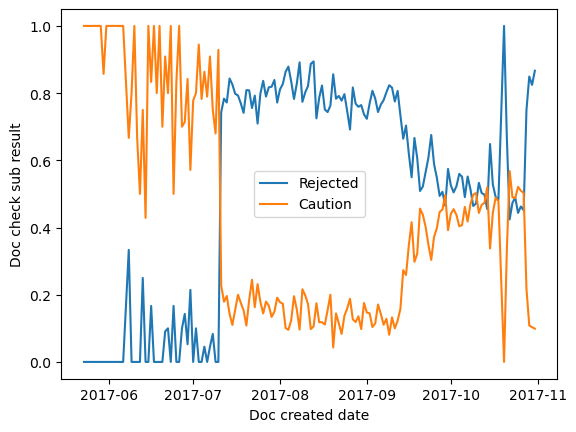

In [63]:
# Doc check sub results over time 
plt.plot(doc_sub_result['doc_created_date'],doc_sub_result['rejected_sub_result'] / doc_sub_result['failed_doc_checks'], label='Rejected')
plt.plot(doc_sub_result['doc_created_date'],doc_sub_result['caution_sub_result'] / doc_sub_result['failed_doc_checks'], label='Caution')
plt.legend()
plt.xlabel('Doc created date')
plt.ylabel('Doc check sub result')
plt.show()

#### Analysis of users with rejected document check sub-result

In [64]:
# Drivers of rejected document check sub-result 
rejected_doc_result = required_tests[required_tests['doc_sub_result']=='rejected']

In [65]:
rejected_doc_result['image_integrity_result'].value_counts()

image_integrity_result
consider    24191
Name: count, dtype: int64

In [66]:
# Define outcomes
outcomes = ['clear','consider','unidentfied']

# Columns to check: Document check sub-result is driven by these columns based on KYC process description 
cols_to_check = ['image_quality_result','supported_document_result', 'conclusive_document_quality_result',
       'colour_picture_result']

# Count occurences per column
iir_analysis = pd.DataFrame({
    col: rejected_doc_result[col].value_counts()
    for col in cols_to_check
})

In [67]:
iir_analysis

,image_quality_result,supported_document_result,conclusive_document_quality_result,colour_picture_result
clear,1514,22196,NaN,NaN
unidentified,22677,1514,NaN,NaN


In [68]:
# Check documents for rejected doc check results
document_analysis = required_tests.merge(doc_expanded, on=['user_id','attempt_id'],how='left')

In [69]:
# Expired document filter 
document_analysis['expired_document'] = document_analysis.apply(lambda row: 1 if pd.notna(row['date_of_expiry']) and row['doc_created_date'] >= row['date_of_expiry'] else 0, axis=1)

In [70]:
len(document_analysis)

166688

In [71]:
rejected_documents = document_analysis[document_analysis['doc_sub_result']=='rejected']

In [72]:
# Check documents details for rejected submissions
rejected_documents[[ 'gender', 'nationality', 'document_type',
       'date_of_expiry', 'issuing_country', 'issuing_date', 'issuing_state',
       'document_version']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 24191 entries, 652 to 166501
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            1 non-null      object
 1   nationality       2 non-null      object
 2   document_type     8 non-null      object
 3   date_of_expiry    1 non-null      object
 4   issuing_country   11 non-null     object
 5   issuing_date      0 non-null      object
 6   issuing_state     0 non-null      object
 7   document_version  0 non-null      object
dtypes: object(8)
memory usage: 1.7+ MB


#### Analysis of users with caution document check sub-result

In [73]:
# Caution doc sub-result analysis
caution_doc_result = required_tests[required_tests['doc_sub_result']=='caution']

In [150]:
# Number of caution document sub-results
len(caution_doc_result)

14484

In [74]:
# Columns to check
cols_to_check = ['visual_authenticity_result', 'image_integrity_result',
       'face_detection_result','data_validation_result',
       'data_consistency_result', 'data_comparison_result',
       'police_record_result']

# Count occurences per column
caution_analysis = pd.DataFrame({
    col: caution_doc_result[col].value_counts()
    for col in cols_to_check
})

In [75]:
# 
caution_analysis

,visual_authenticity_result,image_integrity_result,face_detection_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result
clear,13203,2275,13978,13020,8949.0,32,14121.0
consider,1265,12209,487,1095,NaN,162,NaN


In [76]:
# Deep dive into image integrity issues causing caution sub-result
cols_to_check = ['image_quality_result','supported_document_result', 'conclusive_document_quality_result',
       'colour_picture_result']

caution_image_analysis = pd.DataFrame({
    col: caution_doc_result[col].value_counts()
    for col in cols_to_check
})

In [77]:
caution_image_analysis

,image_quality_result,supported_document_result,conclusive_document_quality_result,colour_picture_result
clear,14484.0,14484.0,1015,13114
consider,NaN,NaN,12160,61


#### Deep dive into users with caution sub-result and consider IIR

In [78]:
caution_documents = document_analysis[(document_analysis['doc_sub_result']=='caution')&(document_analysis['image_integrity_result']=='consider')]

In [147]:
# Data summary to identify potential issues
caution_documents[[ 'gender', 'nationality', 'document_type',
       'date_of_expiry', 'issuing_country', 'issuing_date', 'issuing_state',
       'document_version']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 12209 entries, 656 to 161508
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            10698 non-null  object
 1   nationality       6969 non-null   object
 2   document_type     12209 non-null  object
 3   date_of_expiry    11256 non-null  object
 4   issuing_country   12209 non-null  object
 5   issuing_date      654 non-null    object
 6   issuing_state     19 non-null     object
 7   document_version  2 non-null      object
dtypes: object(8)
memory usage: 858.4+ KB


#### Results by document type

In [86]:
doc_type_results = document_analysis.groupby('document_type', dropna=False).agg(
    doc_type = ('user_id','count'),
    doc_clear = ('doc_sub_result',lambda x: (x=='clear').sum()),
    doc_rejected = ('doc_sub_result', lambda x: (x=='rejected').sum()),
    doc_caution = ('doc_sub_result', lambda x: (x=='caution').sum()),
    doc_suspected = ('doc_sub_result', lambda x: (x=='suspected').sum()),
).reset_index()

In [87]:
# Add row-wise percentage contribution as new columns 

# Name of columns to be used as input
input_cols = ['doc_clear','doc_rejected','doc_caution','doc_suspected']

# Add percentage columns 
for col in input_cols:
    doc_type_results[f'{col}_pct'] = (doc_type_results[col] / doc_type_results['doc_type']).round(4)

In [88]:
doc_type_results

,document_type,doc_type,doc_clear,doc_rejected,doc_caution,doc_suspected,doc_clear_pct,doc_rejected_pct,doc_caution_pct,doc_suspected_pct
0,driving_licence,47894,42811,7,4889,187,0.8939,0.0001,0.1021,0.0039
1,national_identity_card,52077,47743,1,3627,706,0.9168,0.0000,0.0696,0.0136
2,passport,39964,33434,0,5736,794,0.8366,0.0000,0.1435,0.0199
3,residence_permit,2519,2245,0,215,59,0.8912,0.0000,0.0854,0.0234
4,tax_id,6,6,0,0,0,1.0000,0.0000,0.0000,0.0000
5,voter_id,10,10,0,0,0,1.0000,0.0000,0.0000,0.0000
6,work_permit,17,16,0,1,0,0.9412,0.0000,0.0588,0.0000
7,NaN,24201,2,24183,16,0,0.0001,0.9993,0.0007,0.0000


#### Results by issuing country

In [182]:
issuing_country_results = document_analysis.groupby('issuing_country', dropna=False).agg(
    doc_type = ('user_id','count'),
    doc_clear = ('doc_sub_result',lambda x: (x=='clear').sum()),
    doc_rejected = ('doc_sub_result', lambda x: (x=='rejected').sum()),
    doc_caution = ('doc_sub_result', lambda x: (x=='caution').sum()),
    doc_suspected = ('doc_sub_result', lambda x: (x=='suspected').sum()),
).reset_index()

In [183]:
# Add row-wise percentage contribution as new columns 

# Name of columns to be used as input
input_cols = ['doc_clear','doc_rejected','doc_caution','doc_suspected']

# Add percentage columns 
for col in input_cols:
    issuing_country_results[f'{col}_pct'] = (issuing_country_results[col] / issuing_country_results['doc_type']).round(4)

In [186]:
issuing_country_results = issuing_country_results.sort_values(by='doc_type',ascending=False)
issuing_country_results_subset = issuing_country_results[issuing_country_results['doc_type']>=1000]
issuing_country_results_subset

,issuing_country,doc_type,doc_clear,doc_rejected,doc_caution,doc_suspected,doc_clear_pct,doc_rejected_pct,doc_caution_pct,doc_suspected_pct
53,GBR,37460,31940,0,5232,288,0.8526,0.0000,0.1397,0.0077
167,NaN,24197,1,24180,16,0,0.0000,0.9993,0.0007,0.0000
50,FRA,22404,20152,0,1891,361,0.8995,0.0000,0.0844,0.0161
94,LTU,12362,11121,1,1168,72,0.8996,0.0001,0.0945,0.0058
46,ESP,9043,8271,0,683,89,0.9146,0.0000,0.0755,0.0098
71,IRL,8803,7579,2,1070,152,0.8610,0.0002,0.1215,0.0173
123,POL,8736,8031,0,661,44,0.9193,0.0000,0.0757,0.0050
124,PRT,5258,4696,0,513,49,0.8931,0.0000,0.0976,0.0093
76,ITA,4564,3898,1,563,102,0.8541,0.0002,0.1234,0.0223
39,DEU,4178,3706,1,424,47,0.8870,0.0002,0.1015,0.0112


#### Users with expired documents

In [155]:
# Check if tests failed due to expried documents
expired_doc_overview = caution_documents.groupby('expired_document').size().reset_index()

# Renaming columns 
expired_doc_overview.columns = ['expired_document','test_count']

# Adding percentage contribution to overall 
expired_doc_overview['percentage'] = expired_doc_overview['test_count'] / expired_doc_overview['test_count'].sum()

# Showing results
expired_doc_overview

,expired_document,test_count,percentage
0,0,12102,0.991236
1,1,107,0.008764


### Analysis of users with multiple tries

In [95]:
#multiple_tries = multiple_tries.drop('neccesassary_check', axis=1)
multiple_tries.head()

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,facial_check_fail,failed_both_checks,only_doc_check_fail,only_facial_check_fail,kyc_pass,user_id_count,order,previous_kyc,has_previous_pass,necessary_check
17,17,b20147d91fdf4ac289ddd80c4be9716a,2db4bd5ed28948af858881e5e261bc2d,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,0,0,0,0,1,2,1,NaN,NaN,1
18,18,b20147d91fdf4ac289ddd80c4be9716a,aa906e5f7be04ebca1d79091f5294f58,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,0,0,0,0,1,2,2,1.0,1.0,0
24,24,7e66b2c14ea74d28af5547be220455dd,e3549a16f4054976a7a994f1b268d195,clear,clear,2017-06-20 19:39:10+00:00,clear,clear,clear,clear,...,0,0,0,0,1,3,1,NaN,NaN,1
32,32,80335b5bfe4241b9906b52ca4bac0dc2,863121e980074e3c946c451865627ec3,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,0,0,0,0,1,2,1,NaN,NaN,1
33,33,80335b5bfe4241b9906b52ca4bac0dc2,155bb52483974dc2a8f7beedfc740ec1,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,0,0,0,0,1,2,2,1.0,1.0,0


In [97]:
# Count unique users with unnecessary checks 
users_with_unnecessary_checks = multiple_tries[multiple_tries['necessary_check']==0]['user_id'].nunique()

In [99]:
# Create a summary table with multiple tries details
summary = {
    'unique_users':[multiple_tries['user_id'].nunique()],
    'total_attemps':[multiple_tries.shape[0]],
    'users_with_unnecessary_checks':[users_with_unnecessary_checks],
    'unnecessary_checks':[multiple_tries[multiple_tries['necessary_check'] == 0].shape[0]]
}

# Convert to a DF
summary_df = pd.DataFrame(summary)

In [100]:
summary_df

,unique_users,total_attemps,users_with_unnecessary_checks,unnecessary_checks
0,32350,66030,9136,9716


In [102]:
# Unnecessary checks over time
summary_over_time = multiple_tries.groupby('doc_created_date').agg(
    unique_users = ('user_id','nunique'),
    total_attempts = ('number','count'),
    unnecessary_checks = ('necessary_check', lambda x: (x==0).sum())
).reset_index()

In [103]:
summary_over_time['pct_unnecessary_check'] = summary_over_time['unnecessary_checks'] / summary_over_time['total_attempts']

In [104]:
summary_over_time

,doc_created_date,unique_users,total_attempts,unnecessary_checks,pct_unnecessary_check
0,2017-05-23,10,19,3,0.157895
1,2017-05-24,16,32,7,0.218750
2,2017-05-25,12,20,7,0.350000
3,2017-05-26,23,43,13,0.302326
4,2017-05-27,16,32,11,0.343750
...,...,...,...,...,...
155,2017-10-27,552,999,126,0.126126
156,2017-10-28,349,610,89,0.145902
157,2017-10-29,275,489,45,0.092025
158,2017-10-30,255,452,40,0.088496


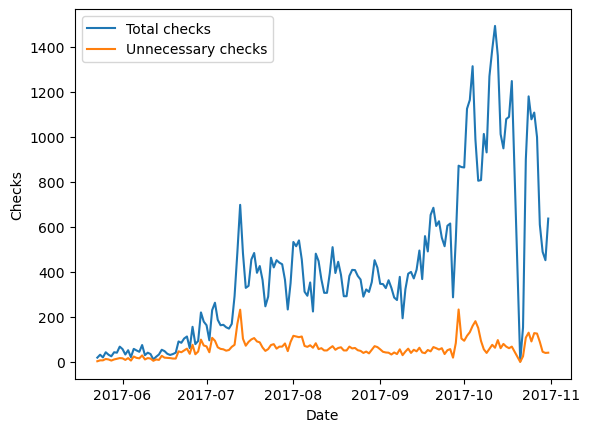

In [105]:
# Number of checks and unnecessary checks
plt.plot(summary_over_time['doc_created_date'], summary_over_time['total_attempts'],label='Total checks')
plt.plot(summary_over_time['doc_created_date'], summary_over_time['unnecessary_checks'], label='Unnecessary checks')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Checks')
plt.show()

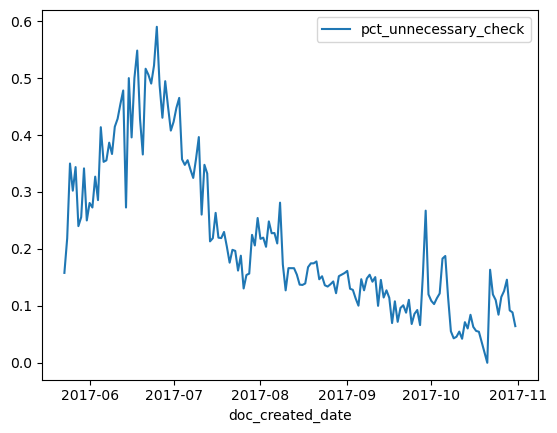

In [106]:
# Percentage of unnecessary checks
summary_over_time.plot(x='doc_created_date',y='pct_unnecessary_check')
plt.show()

### Analysis

In [107]:
# Display doc result over time 
doc_results = combined_check_results.groupby(['doc_created_date','doc_result']).size().unstack(fill_value=0) # Without .unstack(), you'd need extra logic to turn that multi-index Series into a usable table. With .unstack(), it's done in one line.

In [108]:
doc_results['doc_checks'] = doc_results['clear'] + doc_results['consider']

In [109]:
doc_results['clear_pct'] = doc_results['clear'] / (doc_results['clear'] + doc_results['consider']) 

In [110]:
doc_results

doc_result,clear,consider,doc_checks,clear_pct
doc_created_date,,,,
2017-05-23,91,9,100,0.910000
2017-05-24,178,16,194,0.917526
2017-05-25,150,15,165,0.909091
2017-05-26,194,19,213,0.910798
2017-05-27,159,15,174,0.913793
...,...,...,...,...
2017-10-27,1188,815,2003,0.593110
2017-10-28,1064,425,1489,0.714574
2017-10-29,1042,351,1393,0.748026


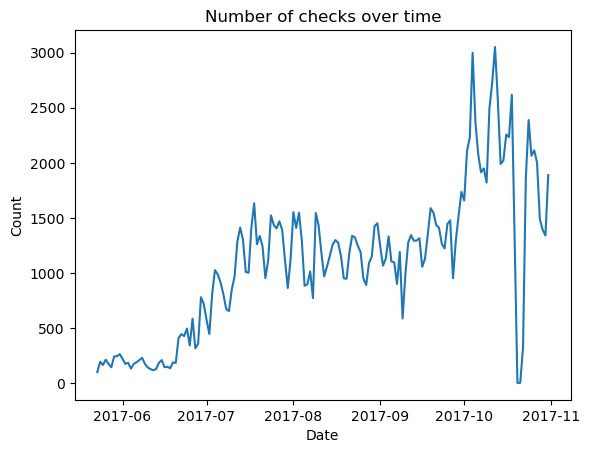

In [111]:
doc_results['doc_checks'].plot(kind='line')
plt.title('Number of checks over time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

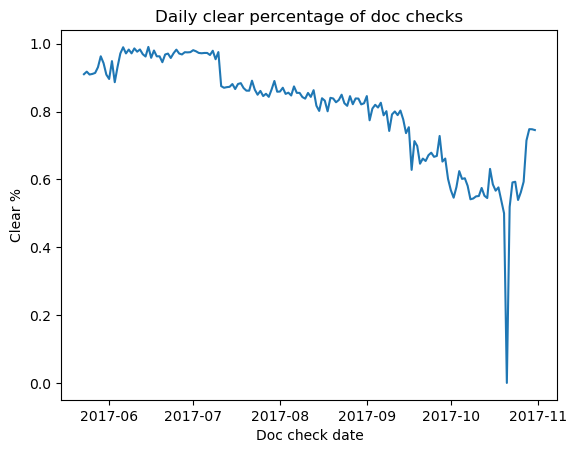

In [112]:
# Make the chart interactive

# Check clear contribution over time
doc_results['clear_pct'].plot(kind='line')
plt.title('Daily clear percentage of doc checks')
plt.xlabel('Doc check date')
plt.ylabel('Clear %')

#plt.gca().yaxis.set_major_formatter(PercentFormatter())

plt.show()

In [113]:
# Entries where both facial and document checks are clear 
combined_check_results['kyc_pass'] = combined_check_results.apply(lambda row: 1 if row['facial_result']=='clear' and row['doc_result']=='clear' else 0,axis=1)

In [114]:
# Calcualte if the user passed at least once
user_pass_rate = combined_check_results.groupby('user_id')['kyc_pass'].max()

In [115]:
user_pass_rate

user_id
000017082a4548d4aa480781069cf24c    1
000052fe85524411a593a999c2a24462    1
0000ae3e6cad4aa6b22a70c141cfebea    0
0001c1eacfdd4f1580b024de206c61e6    1
000215b70cd5498fa7384d7ccdc166c8    1
                                   ..
fffdf0314d2a42c8922e5b459804857b    1
fffe24c9067c41c5b217e25f457f4c45    1
fffe793811f24cdab0d6dca6c615d89c    1
ffff69137fd8419a8b2f521368cccce6    1
ffffb23498da427595799b6ecda5f70b    1
Name: kyc_pass, Length: 142724, dtype: int64

In [116]:
overall_pass_rate = user_pass_rate.mean()

In [117]:
overall_pass_rate

0.8509220593593229

In [118]:
# Combine data and user level data
user_pass_rate = combined_check_results.groupby(['user_id','doc_created_date'])['kyc_pass'].max().reset_index()

In [119]:
user_pass_rate

,user_id,doc_created_date,kyc_pass
0,000017082a4548d4aa480781069cf24c,2017-08-17,1
1,000052fe85524411a593a999c2a24462,2017-07-26,1
2,0000ae3e6cad4aa6b22a70c141cfebea,2017-10-04,0
3,0001c1eacfdd4f1580b024de206c61e6,2017-10-24,1
4,000215b70cd5498fa7384d7ccdc166c8,2017-07-29,1
...,...,...,...
148425,fffdf0314d2a42c8922e5b459804857b,2017-10-18,1
148426,fffe24c9067c41c5b217e25f457f4c45,2017-07-31,1
148427,fffe793811f24cdab0d6dca6c615d89c,2017-10-16,1
148428,ffff69137fd8419a8b2f521368cccce6,2017-10-28,1


In [120]:
date_pass_rate = user_pass_rate.groupby('doc_created_date')['kyc_pass'].mean().reset_index()

In [121]:
daily_tries = user_pass_rate.groupby('doc_created_date')['user_id'].nunique().reset_index()

In [122]:
daily_tries.rename(columns={'user_id':'unique_tries'},inplace=True)
daily_tries

,doc_created_date,unique_tries
0,2017-05-23,91
1,2017-05-24,178
2,2017-05-25,157
3,2017-05-26,193
4,2017-05-27,158
...,...,...
156,2017-10-27,1556
157,2017-10-28,1228
158,2017-10-29,1179
159,2017-10-30,1143


In [123]:
# Idea: Post two charts next to each other: number of unique users per day and kyc pass rate 

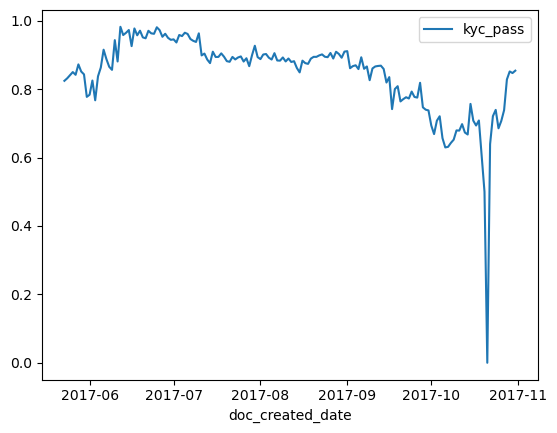

In [124]:
date_pass_rate.plot(x='doc_created_date', y='kyc_pass',kind='line')
plt.show()

In [125]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_sub_result,doc_created_date,doc_check_fail,facial_check_fail,failed_both_checks,only_doc_check_fail,only_facial_check_fail,kyc_pass,user_id_count,order
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,clear,...,caution,2017-06-20,1,0,0,1,0,0,1,1
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,1,1
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,1,1
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,1,1
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,1,1
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,1,1
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,2,2
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,clear,2017-06-20,0,0,0,0,0,1,1,1


In [126]:
# see if fail is driven by facial or doc check results
combined_check_results['doc_fail'] = combined_check_results['doc_result'].apply(lambda x: 1 if x != 'clear' else 0)

In [127]:
combined_check_results['facial_fail'] = combined_check_results['facial_result'].map(lambda x: 1 if x !='clear' else 0)

In [128]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_check_fail,facial_check_fail,failed_both_checks,only_doc_check_fail,only_facial_check_fail,kyc_pass,user_id_count,order,doc_fail,facial_fail
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,clear,...,1,0,0,1,0,0,1,1,1,0
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,2,0,0
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0


In [129]:
# Users with multiple tries
combined_check_results['user_id_count'] = combined_check_results.groupby('user_id')['user_id'].transform('count')

In [130]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_check_fail,facial_check_fail,failed_both_checks,only_doc_check_fail,only_facial_check_fail,kyc_pass,user_id_count,order,doc_fail,facial_fail
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,clear,...,1,0,0,1,0,0,1,1,1,0
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,2,0,0
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,1,1,0,0


In [131]:
# Multiple tries and clear both 
multiple_tries = combined_check_results[combined_check_results['user_id_count']>1]

In [132]:
# Add order to show sequence of tests at user level
multiple_tries.loc[:,'order'] = multiple_tries.sort_values(by=['user_id','number']).groupby('user_id').cumcount()+1

In [133]:
multiple_tries

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_check_fail,facial_check_fail,failed_both_checks,only_doc_check_fail,only_facial_check_fail,kyc_pass,user_id_count,order,doc_fail,facial_fail
17,17,b20147d91fdf4ac289ddd80c4be9716a,2db4bd5ed28948af858881e5e261bc2d,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,1,0,0
18,18,b20147d91fdf4ac289ddd80c4be9716a,aa906e5f7be04ebca1d79091f5294f58,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,2,0,0
24,24,7e66b2c14ea74d28af5547be220455dd,e3549a16f4054976a7a994f1b268d195,clear,clear,2017-06-20 19:39:10+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,1,0,0
32,32,80335b5bfe4241b9906b52ca4bac0dc2,863121e980074e3c946c451865627ec3,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,1,0,0
33,33,80335b5bfe4241b9906b52ca4bac0dc2,155bb52483974dc2a8f7beedfc740ec1,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176389,181977,a0d443689ede49ab8c29f00662621e55,538536eeebbf446daf75f4b0851a6133,clear,clear,2017-06-20 20:59:39+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,1,0,0
176390,181978,a0d443689ede49ab8c29f00662621e55,8e626ecf669b4ab8b0b86f95dfdf85a1,clear,clear,2017-06-20 20:59:39+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,2,0,0
176397,181985,cafb2c8a27b941cbb0d72f5889fc9911,08fbfeda3f38452e8ab36536b0a7adea,consider,NaN,2017-06-20 22:09:59+00:00,consider,clear,clear,clear,...,0,1,0,0,1,0,2,2,0,1
176398,181986,3d16e02c245a4f1a8a76662ad933d5c4,5adad81d87ed46d3b0c3b9214af9d80d,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,2,1,0,0


In [134]:
# Create a summary table with multiple tries details
summary = {
    'unique_users':[multiple_tries['user_id'].nunique()],
    'total_attemps':[multiple_tries.shape[0]],
}

# Convert to a DF
summary_df = pd.DataFrame(summary)

In [135]:
summary_df

,unique_users,total_attemps
0,32350,66030


In [136]:
first_attempt_passed = multiple_tries[(multiple_tries['kyc_pass'] ==1) & (multiple_tries['order']==1)]

In [137]:
fa_test = first_attempt_passed.agg({
   'user_id':'nunique',
    'user_id_count':'sum'
})

# convert to DF
first_attempt_df = fa_test.to_frame().T

In [138]:
first_attempt_df

,user_id,user_id_count
0,8947,18466


In [139]:
# Users who passed kyc on second try but had 3 sumbmissions
second_attempt_passed = multiple_tries[(~multiple_tries['user_id'].isin(first_attempt_passed['user_id'])) & (multiple_tries['kyc_pass'] ==1) & (multiple_tries['order']==2) & (multiple_tries['user_id_count']==3)]

In [140]:
second_attempt_passed

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_check_fail,facial_check_fail,failed_both_checks,only_doc_check_fail,only_facial_check_fail,kyc_pass,user_id_count,order,doc_fail,facial_fail
199,199,efc249ccdd11480688963cdd719a0ab6,c91a8f2f191646c6b8c8540a85695542,clear,clear,2017-06-19 13:29:45+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
4027,4577,25d8ce746f134e20b41f4ad1e5b3b44b,a86825dc95c84462bce2909d1bb9db5a,clear,clear,2017-10-30 15:06:30+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
4672,5325,b6ffa9898a9b40a5a7049de30a37175d,0ad3a98d7c174393a158cf8dd89e7507,clear,clear,2017-10-30 03:12:50+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
4999,5672,350ffaf727054604a3cd857d50814fda,afddc8e1f05d464182f83d73ecb2f4dc,clear,clear,2017-10-29 19:10:02+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
5522,6223,3c61645d0a6b40aeb68ad4a13e06f724,b4d4971cc1204eb08ade13a9bc577421,clear,clear,2017-10-29 12:32:57+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169718,175296,561a2f5d4c544043a660178bdf9535ca,d011eb13dbc14fa8b5e60c16859653a1,clear,clear,2017-07-07 23:45:28+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
170458,176037,8c532c7d94124627acaafc8205e0f7d4,165f098e0b84489c973edb8ada15b766,clear,clear,2017-07-06 17:09:05+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
172301,177888,ea3d7bed80354e86baa69ec3fe6a2d51,ce857256fa774393ad57dd003fc1dc0b,clear,clear,2017-07-03 15:13:28+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0
173890,179478,449527ac8b0840f1adc6e4b2de36e53d,b70ecfc5b99c4fd7867a2bf3a78d2525,clear,clear,2017-06-29 15:36:55+00:00,clear,clear,clear,clear,...,0,0,0,0,0,1,3,2,0,0


In [141]:
second_attempt_df ={
    'unique_users': [second_attempt_passed['user_id'].nunique()],
    'unneccessary_attempts' : [second_attempt_passed['user_id'].nunique()]
}

In [142]:
# Prevent users to submit new test if they passed one already 

In [143]:
# Add results to summary DF
summary_df['users_with_unneccessary_checks'] = first_attempt_df['user_id'] + second_attempt_df['unique_users']
summary_df['unneccessary_attempts'] = first_attempt_df['user_id_count'] - first_attempt_df['user_id'] + second_attempt_df['unneccessary_attempts']

In [144]:
summary_df

,unique_users,total_attemps,users_with_unneccessary_checks,unneccessary_attempts
0,32350,66030,9129,9701


In [145]:
# Percentage of users with unneccessary checks
print(summary_df['users_with_unneccessary_checks'] / summary_df['unique_users'])

0    0.282195
dtype: float64


In [146]:
#multiple_tries.to_csv('test.csv')
#multiple_tries[multiple_tries['user_id_count']==5].sort_values(by=['user_id','number'])

### To be deleted

### results by document type

In [172]:
pivot_table = document_analysis.pivot_table(
    values='user_id',
    index='doc_sub_result',
    columns='document_type',
    aggfunc='count',
   # margins=True
)

In [173]:
pivot_table

document_type,driving_licence,national_identity_card,passport,residence_permit,tax_id,voter_id,work_permit
doc_sub_result,,,,,,,
caution,4889.0,3627.0,5736.0,215.0,NaN,NaN,1.0
clear,42811.0,47743.0,33434.0,2245.0,6.0,10.0,16.0
rejected,7.0,1.0,NaN,NaN,NaN,NaN,NaN
suspected,187.0,706.0,794.0,59.0,NaN,NaN,NaN


In [174]:
new_df = pivot_table.reset_index()

In [175]:
new_df

document_type,doc_sub_result,driving_licence,national_identity_card,passport,residence_permit,tax_id,voter_id,work_permit
0,caution,4889.0,3627.0,5736.0,215.0,NaN,NaN,1.0
1,clear,42811.0,47743.0,33434.0,2245.0,6.0,10.0,16.0
2,rejected,7.0,1.0,NaN,NaN,NaN,NaN,NaN
3,suspected,187.0,706.0,794.0,59.0,NaN,NaN,NaN


In [181]:
# Remove document_type metadata
new_df.columns.name = None

# Display results by 
new_df

,doc_sub_result,driving_licence,national_identity_card,passport,residence_permit,tax_id,voter_id,work_permit
0,caution,4889.0,3627.0,5736.0,215.0,NaN,NaN,1.0
1,clear,42811.0,47743.0,33434.0,2245.0,6.0,10.0,16.0
2,rejected,7.0,1.0,NaN,NaN,NaN,NaN,NaN
3,suspected,187.0,706.0,794.0,59.0,NaN,NaN,NaN
